# 🏆 Notebook 2: Optuna Tuning, Explainability & Champion Model

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import xgboost as xgb
import optuna
import shap

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Load Processed Data

In [2]:
train_df = pd.read_csv('../../data/processed/train_processed.csv')
test_df = pd.read_csv('../../data/processed/test_processed.csv')

X_train = train_df.drop('target', axis=1)
y_train = train_df['target']

X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"📊 X_train shape: {X_train.shape}")
print(f"⚖️ Imbalance Ratio (Neg/Pos): {imbalance_ratio:.2f}")

📊 X_train shape: (800, 16)
⚖️ Imbalance Ratio (Neg/Pos): 13.81


## 2. Optuna Hyperparameter Tuning
We use Optuna to automatically search for the absolute best parameters for XGBoost.

In [3]:
def objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'n_estimators': 150, # Keep it a bit lower during search for speed
        'scale_pos_weight': imbalance_ratio,
        'random_state': 42,
        'eval_metric': 'auc'
    }
    
    model = xgb.XGBClassifier(**param)
    # Use eval_set to stop early if it stops improving
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    preds = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds)
    return auc

print("🚀 Starting Optuna Study...")
study = optuna.create_study(direction='maximize')
# Note: For production, increase n_trials to 50 or 100.
study.optimize(objective, n_trials=10)

print('\n🏆 Best trial:', study.best_trial.params)
print(f'🏆 Best AUC: {study.best_trial.value:.4f}')

[I 2026-06-16 02:29:20,688] A new study created in memory with name: no-name-cd4b080a-bad2-41c1-b8de-bf1d11117505


🚀 Starting Optuna Study...


[I 2026-06-16 02:29:21,103] Trial 0 finished with value: 0.8725038402457758 and parameters: {'max_depth': 9, 'learning_rate': 0.01869425821952854, 'subsample': 0.7386129013935854, 'colsample_bytree': 0.7597088880696143}. Best is trial 0 with value: 0.8725038402457758.
[I 2026-06-16 02:29:21,221] Trial 1 finished with value: 0.8671274961597543 and parameters: {'max_depth': 4, 'learning_rate': 0.037666749948607456, 'subsample': 0.7758061760532726, 'colsample_bytree': 0.8786893453416863}. Best is trial 0 with value: 0.8725038402457758.
[I 2026-06-16 02:29:21,344] Trial 2 finished with value: 0.8387096774193548 and parameters: {'max_depth': 5, 'learning_rate': 0.23863802836454057, 'subsample': 0.7824269223931613, 'colsample_bytree': 0.9542424464004735}. Best is trial 0 with value: 0.8725038402457758.
[I 2026-06-16 02:29:21,500] Trial 3 finished with value: 0.880184331797235 and parameters: {'max_depth': 7, 'learning_rate': 0.026963568245494025, 'subsample': 0.5239956689167564, 'colsample_b


🏆 Best trial: {'max_depth': 7, 'learning_rate': 0.026963568245494025, 'subsample': 0.5239956689167564, 'colsample_bytree': 0.5299808579388736}
🏆 Best AUC: 0.8802


## 3. Train Champion Model & Save It
We take the best parameters, train our Champion model, and save it for deployment.

In [4]:
# 1. Train Champion
best_params = study.best_trial.params
champion_model = xgb.XGBClassifier(**best_params, n_estimators=300, scale_pos_weight=imbalance_ratio, random_state=42, eval_metric='auc')

print("⚙️ Training Champion XGBoost...")
champion_model.fit(X_train, y_train)

# 2. Evaluate
y_probs = champion_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f"🏆 Final Champion ROC-AUC: {auc:.4f}")

# 3. Save Model to disk
joblib.dump(champion_model, '../../models/champion_xgboost.pkl')
print("💾 Champion Model saved to models/champion_xgboost.pkl")

⚙️ Training Champion XGBoost...
🏆 Final Champion ROC-AUC: 0.8779
💾 Champion Model saved to models/champion_xgboost.pkl


## 4. SHAP Values: Cracking the Black Box

🔍 Calculating SHAP values...


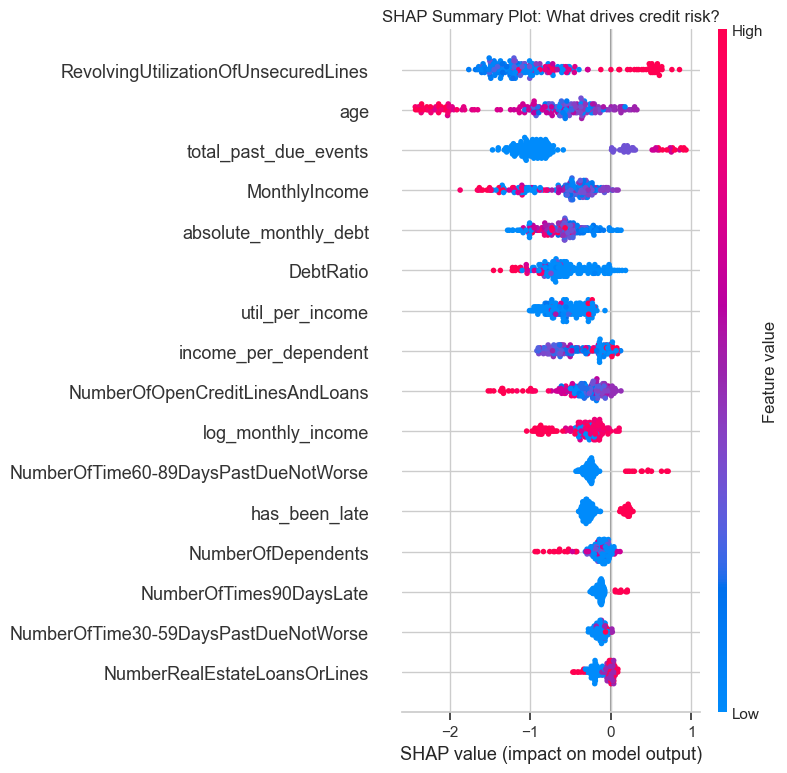

In [6]:
print("🔍 Calculating SHAP values...")
sample_X = X_test.sample(200, random_state=42)
explainer = shap.TreeExplainer(champion_model)
shap_values = explainer(sample_X)

plt.title("SHAP Summary Plot: What drives credit risk?")
shap.summary_plot(shap_values, sample_X)

## 5. Generate Kaggle Submission (Zero Leakage)

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

class CreditRiskFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, cap_outliers=True):
        self.cap_outliers = cap_outliers
        self.upper_bounds = {}
        
    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        if self.cap_outliers:
            for col in X_df.columns:
                if X_df[col].dtype in ['float64', 'int64']:
                    self.upper_bounds[col] = X_df[col].quantile(0.99)
        return self
        
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X_out = pd.DataFrame(X)
        else:
            X_out = X.copy()
            
        if self.cap_outliers:
            for col, upper_bound in self.upper_bounds.items():
                if col in X_out.columns:
                    X_out[col] = np.clip(X_out[col], a_min=None, a_max=upper_bound)
                    
        if 'MonthlyIncome' in X_out.columns:
            X_out['log_monthly_income'] = np.log1p(X_out['MonthlyIncome'].fillna(0))
            
        if 'RevolvingUtilizationOfUnsecuredLines' in X_out.columns and 'MonthlyIncome' in X_out.columns:
            X_out['util_per_income'] = X_out['RevolvingUtilizationOfUnsecuredLines'] / (X_out['MonthlyIncome'].fillna(0) + 1)
            
        delinq_cols = ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']
        if all(c in X_out.columns for c in delinq_cols):
            X_out['total_past_due_events'] = X_out[delinq_cols].sum(axis=1)
            X_out['has_been_late'] = (X_out['total_past_due_events'] > 0).astype(int)
            
        if 'MonthlyIncome' in X_out.columns and 'NumberOfDependents' in X_out.columns:
            X_out['income_per_dependent'] = X_out['MonthlyIncome'] / (X_out['NumberOfDependents'].fillna(0) + 1)
            
        if 'DebtRatio' in X_out.columns and 'MonthlyIncome' in X_out.columns:
            conditions = [
                X_out['MonthlyIncome'].isna(),
                X_out['MonthlyIncome'].notna()
            ]
            choices = [
                X_out['DebtRatio'], 
                X_out['DebtRatio'] * X_out['MonthlyIncome']
            ]
            X_out['absolute_monthly_debt'] = np.select(conditions, choices, default=0)

        return X_out

print("✅ Custom Transformer constructed!")

✅ Custom Transformer constructed!


In [9]:
# Using the correct cs-test.csv file
raw_test_data = pd.read_csv('../../data/GiveMeSomeCredit/cs-test.csv')
print(f"Raw Test Data Shape: {raw_test_data.shape}")

master_pipeline = joblib.load('../../models/master_pipeline.pkl')
final_test_processed = master_pipeline.transform(raw_test_data)
print(f"Processed Test Data Shape: {final_test_processed.shape}")

test_probs = champion_model.predict_proba(final_test_processed)[:, 1]

submission = pd.DataFrame({
    'Id': raw_test_data['Unnamed: 0'] if 'Unnamed: 0' in raw_test_data.columns else np.arange(1, len(test_probs) + 1),
    'Probability': test_probs
})

submission.to_csv('my_optuna_submission.csv', index=False)
print(f"\n✅ SUCCESS! Submission saved to 'my_optuna_submission.csv'. Shape: {submission.shape}")

Raw Test Data Shape: (101503, 12)
Processed Test Data Shape: (101503, 16)

✅ SUCCESS! Submission saved to 'my_optuna_submission.csv'. Shape: (101503, 2)
